In [1]:
import Pkg

Pkg.instantiate()

using Pkg

cd(@__DIR__)
Pkg.activate("../")
Pkg.add(url="https://github.com/tp2750/TuningSystems.jl") 
Pkg.add("Plots")

Pkg.add("DSP")
using DSP
using Dates, SonifSismo, CairoMakie
using Statistics
using WAV
using Seis
using DSP: conv
using TuningSystems
using Test
using Plots

archive = DataArchive("C:/Users/lucie/Desktop/mtFujiContinuous/mtFujiContinuous")
push!(LOAD_PATH, "C:/Users/lucie/Desktop/TuningSystems.jl-main/TuningSystems.jl-main/src")
include("C:/Users/lucie/Desktop/sonifSismo.jl-main/examples/sonify_one_trace.jl")

  Activating project at `c:\Users\lucie\Desktop\sonifSismo.jl-main`
    Updating git-repo `https://github.com/tp2750/TuningSystems.jl`
   Resolving package versions...
      Compat entries added for 
     Project No packages added to or removed from `C:\Users\lucie\Desktop\sonifSismo.jl-main\Project.toml`
    Manifest No packages added to or removed from `C:\Users\lucie\Desktop\sonifSismo.jl-main\Manifest.toml`
   Resolving package versions...
      Compat entries added for 
     Project No packages added to or removed from `C:\Users\lucie\Desktop\sonifSismo.jl-main\Project.toml`
    Manifest No packages added to or removed from `C:\Users\lucie\Desktop\sonifSismo.jl-main\Manifest.toml`
   Resolving package versions...
      Compat entries added for 
     Project No packages added to or removed from `C:\Users\lucie\Desktop\sonifSismo.jl-main\Project.toml`
    Manifest No packages added to or removed from `C:\Users\lucie\Desktop\sonifSismo.jl-main\Manifest.toml`


false

In [2]:
archive = DataArchive("C:/Users/lucie/Desktop/mtFujiContinuous/mtFujiContinuous")

available_stations(archive)
available_channels(archive)

33-element Vector{ChannelAvailability}:
 ChannelAvailability("EV", "FJO", "", "E", [Date("2008-05-25"), Date("2008-05-26"), Date("2008-05-27"), Date("2008-05-28"), Date("2008-05-29"), Date("2008-05-30"), Date("2008-05-31")], ["C:\\Users\\lucie\\Desktop\\mtFujiContinuous\\mtFujiContinuous\\mseed\\2008\\05\\25\\EV.FJO..E.20080525.mseed", "C:\\Users\\lucie\\Desktop\\mtFujiContinuous\\mtFujiContinuous\\mseed\\2008\\05\\26\\EV.FJO..E.20080526.mseed", "C:\\Users\\lucie\\Desktop\\mtFujiContinuous\\mtFujiContinuous\\mseed\\2008\\05\\27\\EV.FJO..E.20080527.mseed", "C:\\Users\\lucie\\Desktop\\mtFujiContinuous\\mtFujiContinuous\\mseed\\2008\\05\\28\\EV.FJO..E.20080528.mseed", "C:\\Users\\lucie\\Desktop\\mtFujiContinuous\\mtFujiContinuous\\mseed\\2008\\05\\29\\EV.FJO..E.20080529.mseed", "C:\\Users\\lucie\\Desktop\\mtFujiContinuous\\mtFujiContinuous\\mseed\\2008\\05\\30\\EV.FJO..E.20080530.mseed", "C:\\Users\\lucie\\Desktop\\mtFujiContinuous\\mtFujiContinuous\\mseed\\2008\\05\\31\\EV.FJO..E.2008053

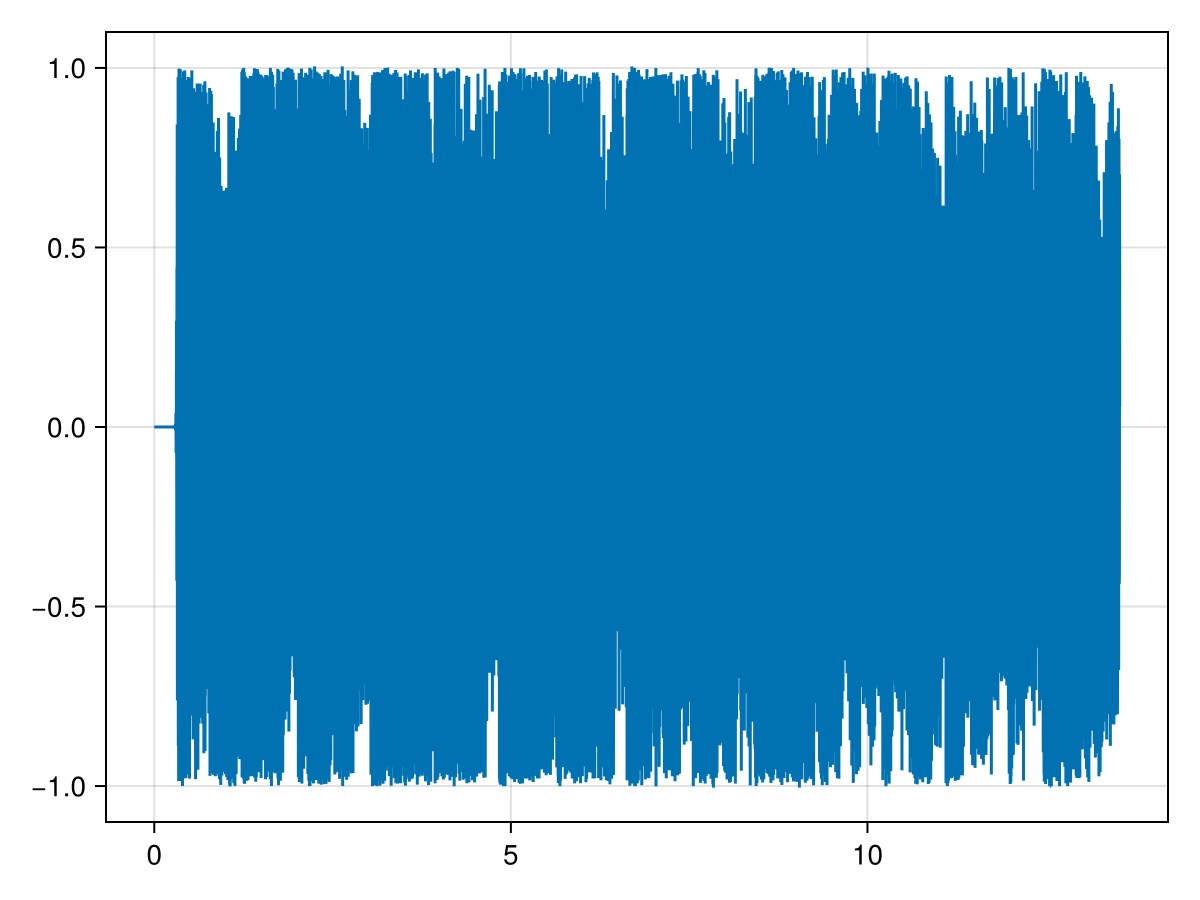

In [38]:
# Enregistrement musique Taylor Swift

using WAV
using Plots

# Charger le fichier audio
y, fs = wavread("C:/Users/lucie/Desktop/Sonification/Let It Be_cut.wav")

# Si stéréo, prendre un seul canal
if ndims(y) > 1
    y = y[:, 1]
end

# Axe temporel - discrétisation
samplerate = 44100
Δt = 1/samplerate
temps = (0:length(y)-1) * Δt

# Tracé
graphe = lines(temps,y)

In [39]:
save("C:/Users/lucie/Desktop/Sonification/Extrait.png", graphe)

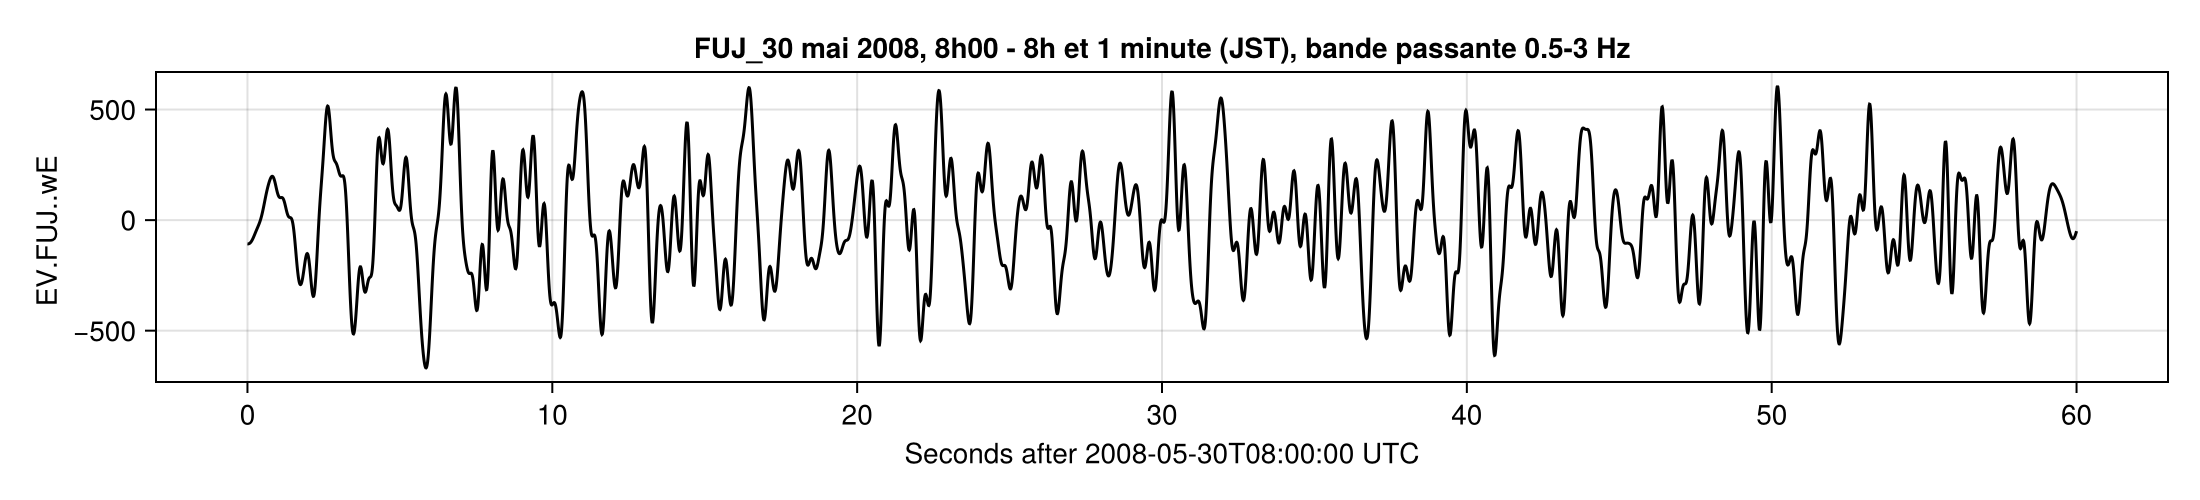

In [40]:
start_time = DateTime(2008, 5, 30, 8, 0, 0)  # UTC
end_time   = DateTime(2008, 5, 30, 8, 1, 0)     # UTC

# TEST 1 - de 0,5 à 3 Hz

traces = read_window(
    archive,
    start_time,
    end_time;
    stations="FUJ",
    channels="wE",
    merge=true,
    processed=true,
    bandpass=(0.5, 3),
)

# Graphe
plot_events = read_catalog(      # Lire les événements pour la période spécifiée
    archive;
    start=start_time,
    stop=end_time,
)

wavefig = plot_waveforms(        # Afficher les formes d'ondes des traces
    traces;
    events=plot_events,
    title="FUJ_30 mai 2008, 8h00 - 8h et 1 minute (JST), bande passante 0.5-3 Hz",
)
wavefig

In [41]:
save("C:/Users/lucie/Desktop/Sonification/Séisme_conv.png", wavefig)

In [50]:
son = sonify_trace(traces[1]; acceleration=4000, level=0.4, gain=1, saturation=:soft)

(signal = [-7.669807603715535e-6, -0.00022465191450669856, -0.00035669714177908435, -0.0003435835428018716, -0.00020439485243046548, 0.0001384566052316226, 0.0008812797814258294, 0.0019313810070051606, 0.0029956394760472954, 0.00375677517783372  …  0.0030729740716737754, 0.0026735186710374866, 0.002024607884467075, 0.0014206281320408882, 0.0008211351943109382, 0.0002292758670152717, -0.00019019663848263328, -0.0003160708271898062, -0.00018076324371400017, -7.669807603715535e-6], sample_rate = 44100, playback_factor = 4000.0, seismic_duration = 60.01, audio_duration = 0.015011337868480726)

In [51]:
Convo = conv(son[1], y)

597649-element Vector{Float64}:
  0.0
  0.0
  0.0
  0.0
  0.0
  0.0
  0.0
  0.0
  0.0
  0.0
  ⋮
  0.0004151042148224846
  0.00021655133462054584
  8.009907538628677e-5
 -4.341545800300509e-6
 -4.431496971397421e-5
 -4.789823189728284e-5
 -3.053632350101358e-5
 -1.0487678735524378e-5
 -4.2249832836460666e-7

In [52]:
wavwrite(Float32.(Convo), "convol_bis.wav")

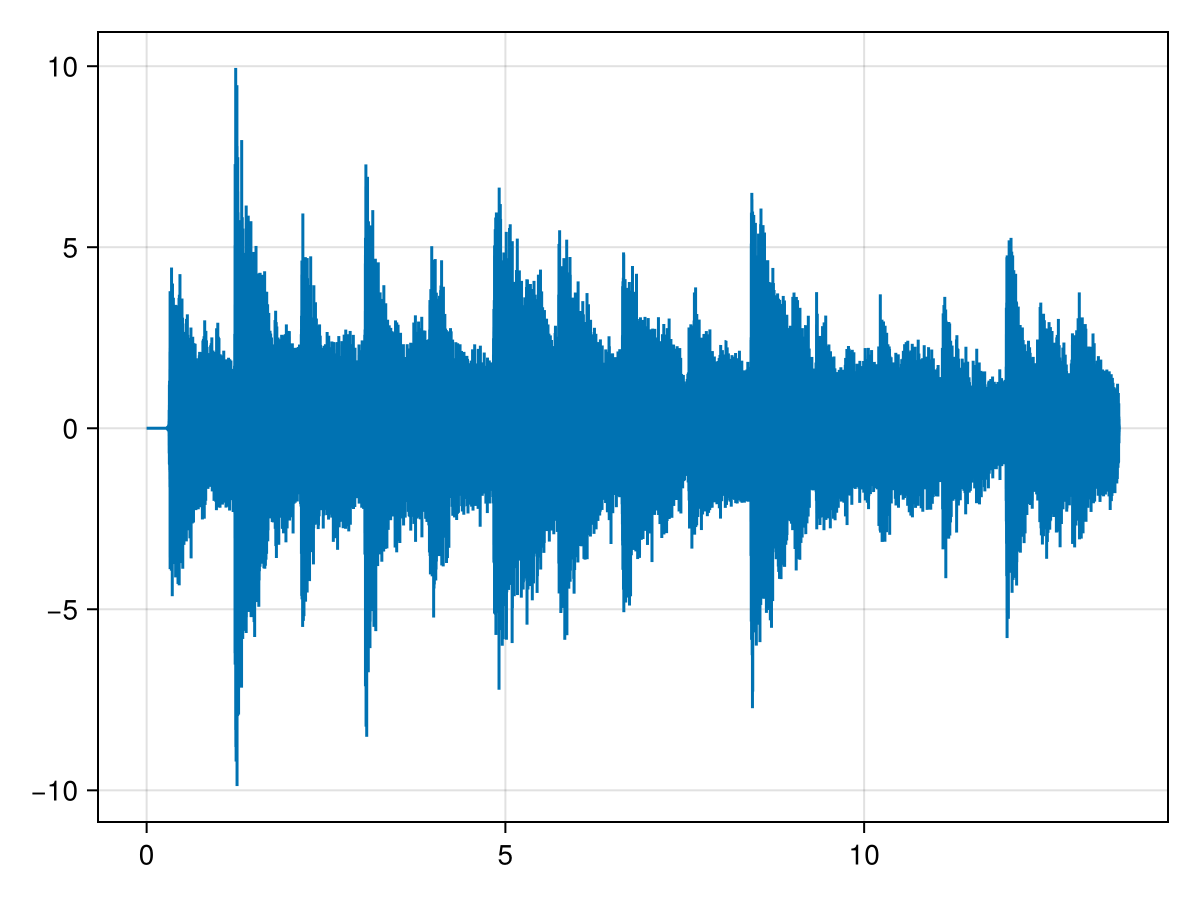

In [45]:
temps_convo = (0:length(Convo)-1) .* Δt

graphique = lines(temps_convo, Convo)

In [46]:
save("C:/Users/lucie/Desktop/Sonification/Graphe_conv.png", graphique)